In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
import statsmodels.stats as ss
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from IPython.display import display
import ipywidgets as widgets
from ipywidgets import interact, IntSlider

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.chdir('/content/drive/My Drive/Colab Notebooks/')

In [5]:
df = pd.read_csv('Data_Limpia.csv')

In [6]:
X = df.drop('IMC', axis=1)
y = df['IMC']

In [7]:
# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir el conjunto de datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Imprimir las formas d+e los conjuntos de entrenamiento y prueba
print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)

Forma de X_train: (842, 86)
Forma de X_test: (211, 86)
Forma de y_train: (842,)


In [8]:
y_test.isnull().sum().sum()

np.int64(0)

In [ ]:
total_ceros = (y_test == 0).sum().sum()
total_ceros

0

#DecisionTreeRegressor

In [10]:
!pip install neptune-client

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.0/488.0 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.0 MB/s eta 0:00:00
  Created wheel for bravado-core: filename=bravado_core-6.1.1-py2.py3-none-any.whl size=67675 sha256=2df93ab01c3848423326ec1362d89ecc29ee774f08759090f1888164ac77fff3
  Stored in directory: /root/.cache/pip/wheels/cf/d7/1c/1d707a21e0a0323bdbfbb2f6de125ae6bb70d62aa2838df321
Successfully built bravado-core


In [12]:
from sklearn.tree import DecisionTreeRegressor
import neptune
from neptune.types import File

# Define tags as a list
tags = ["experimento:Sobrepeso y Obesidad", "arquitectura:DecisionTreeRegressor", "dataset:PRUEBA"]


# Initialize Neptune run (replace with your API token and project info)
api_token = "eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIyNjQwNjNjMS1hNDcwLTRmOGItYTg1MC1hM2ZjM2MzZTZiMjcifQ=="
project = "lilekan39/DTR"
run = neptune.init_run(
    name= "DecisionTreeRegressor",
    project=project,
    api_token=api_token,
    tags=tags

)
# Define hyperparameters
hyperparameters = {
    "max_depth": 3,
    "min_samples_leaf": 10,
}

# Log hyperparameters to Neptune
run["parameters"] = hyperparameters

# Train Decision Tree Regression model
tree_reg = DecisionTreeRegressor(**hyperparameters)
tree_reg.fit(X_train, y_train)

# Make predictions
y_pred_dtr = tree_reg.predict(X_test)

# Calculate and log metrics to Neptune
mse_tree = mean_squared_error(y_test, y_pred_dtr)
r2_tree = r2_score(y_test, y_pred_dtr)
mae_tree = mean_absolute_error(y_test, y_pred_dtr)
rmse_tree = np.sqrt(mse_tree)

run["metrics/mse"] = mse_tree
run["metrics/r2"] = r2_tree
run["metrics/mae"] = mae_tree
run["metrics/rmse"] = rmse_tree

print('MSE:', mse_tree)
print('R2:', r2_tree)
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)

# Optionally save the model as a Neptune artifact (if supported)
# if hasattr(run, 'log_artifact'):  # Check if log_artifact is available
#     model_artifact = File(tree_reg, name='model.pkl')  # Replace with appropriate serialization format
#     run.log_artifact(model_artifact)

# Stop Neptune run
run.stop()

[neptune] [warning] NeptuneDeprecationWarning: The 'neptune-client' package has been deprecated and will be removed in the future. Install the 'neptune' package instead. For more, see https://docs-legacy.neptune.ai/setup/upgrading/
[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs-legacy.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/lilekan39/DTR/e/DTR-162
MSE: 7.813330502173176
R2: 0.7061397191397634
MAE: 2.0847079071282995
RMSE: 2.7952335326718547
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 6 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 6 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/lilekan39/DTR/e/DTR-162/metadata


<ipython-input-14-3769451c0289>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, color='red', label='Línea de referencia')


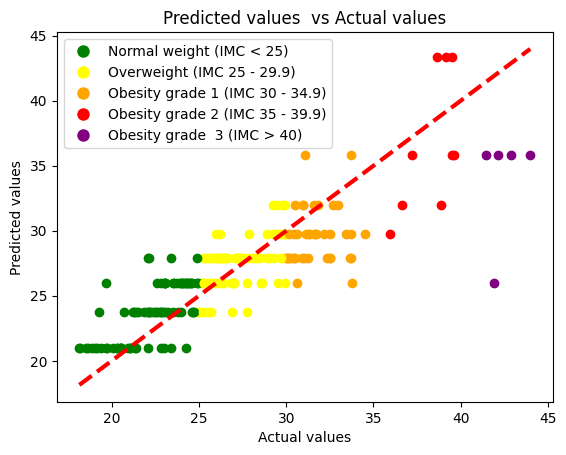

In [14]:
import matplotlib.pyplot as plt

# Definir los rangos de IMC y los colores correspondientes
rangos_imc = [(0, 25), (25, 30), (30, 35), (35, 40), (40, float('inf'))]
colores = ['green', 'yellow', 'orange', 'red', 'purple']
etiquetas = ['Normal weight (IMC < 25)', 'Overweight (IMC 25 - 29.9)', 'Obesity grade 1 (IMC 30 - 34.9)', 'Obesity grade 2 (IMC 35 - 39.9)', 'Obesity grade  3 (IMC > 40)']

# Colorear puntos según los niveles de IMC de y_test
for i in range(len(y_test)):
    imc = y_test.iloc[i]
    for j, (rango_inf, rango_sup) in enumerate(rangos_imc):
        if rango_inf <= imc < rango_sup:
            color = colores[j]
            plt.scatter(y_test.iloc[i], y_pred_dtr[i], color=color)
            break  # Rompe el bucle para evitar colorear el punto más de una vez

# Línea de referencia
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, color='red', label='Línea de referencia')

# Etiquetas y título
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Predicted values  vs Actual values')

# Agregar leyenda
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colores],
           labels=etiquetas, loc='best')

plt.show()

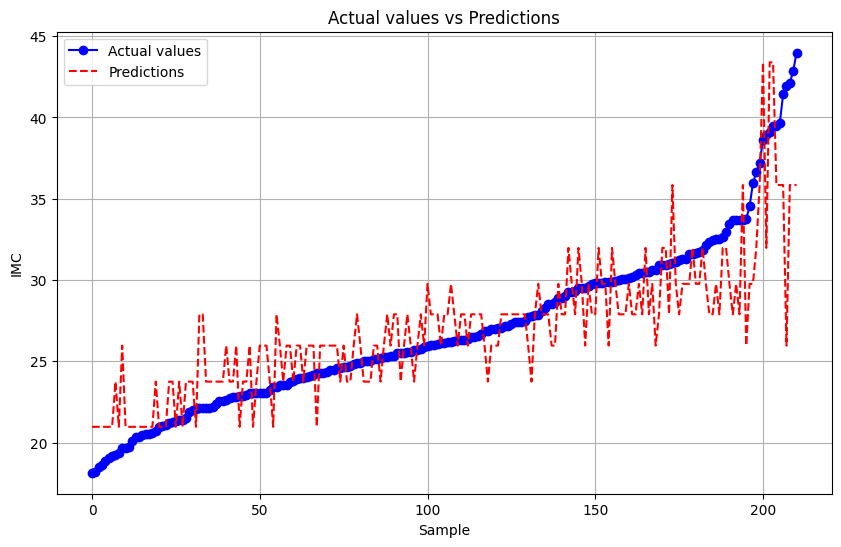

In [17]:
# Ordenar los índices de las muestras para una mejor visualización
sorted_indices = np.argsort(y_test)

# Graficar las predicciones versus los valores reales
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(y_test)), y_test.iloc[sorted_indices], label='Actual values', color='blue', marker='o')
plt.plot(np.arange(len(y_test)), y_pred_dtr[sorted_indices], label='Predictions', color='red', linestyle='--')
plt.xlabel('Sample')
plt.ylabel('IMC')
plt.title('Actual values vs Predictions')
plt.legend()
plt.grid(True)
plt.show()

# Este código generará un gráfico donde cada punto representa una muestra en el conjunto de datos. Los valores reales se muestran en azul y las predicciones en rojo, con líneas conectando las predicciones para resaltar la diferencia entre los valores reales y las predicciones. Este tipo de gráfico puede proporcionar una vista general del rendimiento del modelo en todo el conjunto de datos. Si las líneas de predicción siguen de cerca los puntos de los valores reales, indica que el modelo está produciendo predicciones precisas en general.

In [ ]:
tm

#SVR

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import neptune
from neptune.types import File

# Define tags as a list
tags = ["experimento:Sobrepeso y Obesidad", "arquitectura:SVR", "dataset:PRUEBA"]

# Definir el hiperparámetro
hyperparameter = {"kernel": "rbf"}

# Inicializar la ejecución de Neptune (reemplaza con tu API token e información del proyecto)
api_token = "eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIyNjQwNjNjMS1hNDcwLTRmOGItYTg1MC1hM2ZjM2MzZTZiMjcifQ=="
project = "lilekan39/SVR"
run = neptune.init_run(
    project=project,
    api_token=api_token,
    tags=tags
)

# Registrar el hiperparámetro en Neptune
run["parameters"] = hyperparameter

# Crear y entrenar el modelo SVR
svm_reg = SVR(**hyperparameter)  # Desempaqueta el diccionario para pasar el parámetro
svm_reg.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_svc = svm_reg.predict(X_test)

# Calcular las métricas
from sklearn.metrics import mean_squared_error, r2_score

mse_svr = mean_squared_error(y_test, y_pred_svc)
r2_svr = r2_score(y_test, y_pred_svc)
mae_svr = mean_absolute_error(y_test, y_pred_svc)
rmse_svr = np.sqrt(mse_svr)

# Registrar las métricas en Neptune
run["metrics/mse"] = mse_svr
run["metrics/r2"] = r2_svr
run["metrics/mae"] = mae_svr
run["metrics/rmse"] = rmse_svr

# Imprimir las métricas
print('MSE:', mse_svr)
print('R2:', r2_svr)
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)

# Opcionalmente, guardar el modelo como un artefacto de Neptune (si es compatible)
# if hasattr(run, 'log_artifact'):  # Verificar la disponibilidad de `log_artifact`
#     model_artifact = File(svm_reg, name='model.pkl')  # Reemplazar con el formato de serialización adecuado
#     run.log_artifact(model_artifact)

# Detener la ejecución de Neptune
run.stop()

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/lilekan39/SVR/e/SVR-148
MSE: 5.3203665652831855
R2: 0.7999003865613163
MAE: 1.5949711266178144
RMSE: 2.306591980668273
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 5 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 5 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/lilekan39/SVR/e/SVR-148/metadata


<ipython-input-20-452fcc0171d9>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, color='red', label='Línea de referencia')


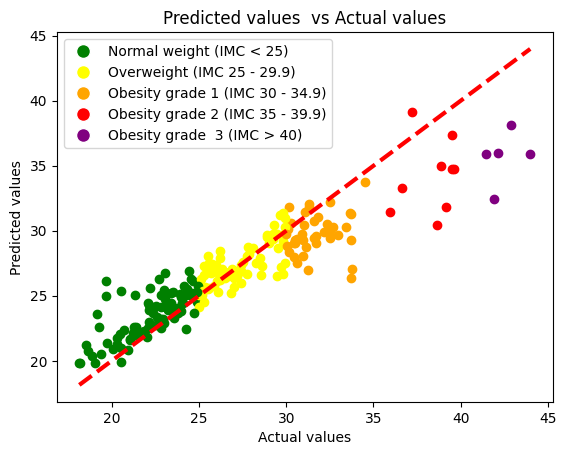

In [20]:
import matplotlib.pyplot as plt

# Definir los rangos de IMC y los colores correspondientes
rangos_imc = [(0, 25), (25, 30), (30, 35), (35, 40), (40, float('inf'))]
colores = ['green', 'yellow', 'orange', 'red', 'purple']
etiquetas = ['Normal weight (IMC < 25)', 'Overweight (IMC 25 - 29.9)', 'Obesity grade 1 (IMC 30 - 34.9)', 'Obesity grade 2 (IMC 35 - 39.9)', 'Obesity grade  3 (IMC > 40)']

# Colorear puntos según los niveles de IMC de y_test
for i in range(len(y_test)):
    imc = y_test.iloc[i]
    for j, (rango_inf, rango_sup) in enumerate(rangos_imc):
        if rango_inf <= imc < rango_sup:
            color = colores[j]
            plt.scatter(y_test.iloc[i], y_pred_svc[i], color=color)
            break  # Rompe el bucle para evitar colorear el punto más de una vez

# Línea de referencia
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, color='red', label='Línea de referencia')

# Etiquetas y título
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Predicted values  vs Actual values')

# Agregar leyenda
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colores],
           labels=etiquetas, loc='best')

plt.show()

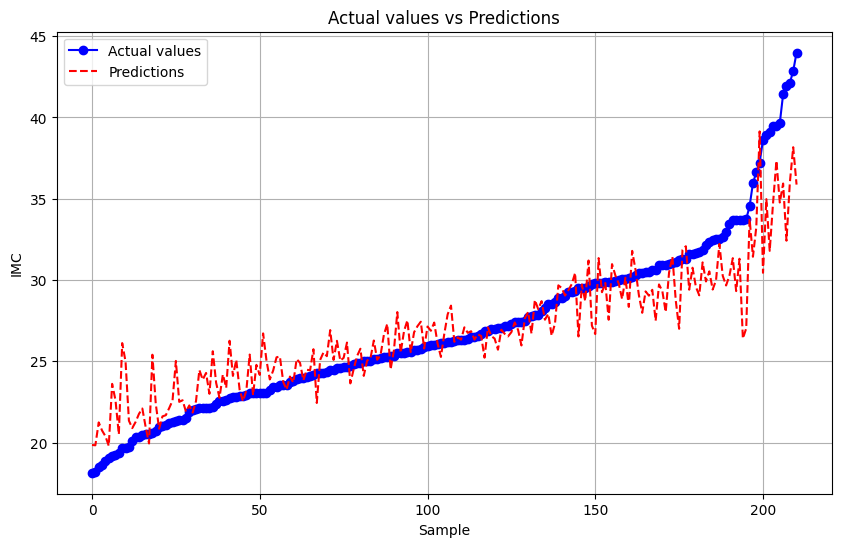

In [21]:
# Ordenar los índices de las muestras para una mejor visualización
sorted_indices = np.argsort(y_test)

# Graficar las predicciones versus los valores reales
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(y_test)), y_test.iloc[sorted_indices], label='Actual values', color='blue', marker='o')
plt.plot(np.arange(len(y_test)), y_pred_svc[sorted_indices], label='Predictions', color='red', linestyle='--')
plt.xlabel('Sample')
plt.ylabel('IMC')
plt.title('Actual values vs Predictions')
plt.legend()
plt.grid(True)
plt.show()

#RandomForestRegressor

In [23]:
from sklearn.ensemble import RandomForestRegressor
import neptune
from neptune.types import File

# Define tags as a list
tags = ["experimento:Sobrepeso y Obesidad", "Arquitectura:RandomForestRegressor", "dataset:PRUEBA"]


# Initialize Neptune run (replace with your API token and project info)
api_token = "eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIyNjQwNjNjMS1hNDcwLTRmOGItYTg1MC1hM2ZjM2MzZTZiMjcifQ=="
project = "lilekan39/RFR"
run = neptune.init_run(
    project=project,
    api_token=api_token,
    tags=tags
)

# Define hyperparameters
hyperparameters = {
    "n_estimators": 100,
    "max_depth": 3,
}

# Log hyperparameters to Neptune
run["parameters"] = hyperparameters

# Train Random Forest Regression model
forest_reg = RandomForestRegressor(**hyperparameters)
forest_reg.fit(X_train, y_train)

# Make predictions
y_pred_rfr = forest_reg.predict(X_test)

# Calculate and log metrics to Neptune
mse_rf = mean_squared_error(y_test, y_pred_rfr)
r2_rf = r2_score(y_test, y_pred_rfr)
mae_rf = mean_absolute_error(y_test, y_pred_rfr)
rmse_rf = np.sqrt(mse_rf)

run["metrics/mse"] = mse_rf
run["metrics/r2"] = r2_rf
run["metrics/mae"] = mae_rf
run["metrics/rmse"] = rmse_rf

print('MSE:', mse_rf)
print('R2:', r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

# Optionally save the model as a Neptune artifact (if supported)
# if hasattr(run, 'log_artifact'):  # Check if log_artifact is available
#     model_artifact = File(forest_reg, name='model.pkl')  # Replace with appropriate serialization format
#     run.log_artifact(model_artifact)

# Stop Neptune run
run.stop()

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/lilekan39/RFR/e/RFR-153
MSE: 6.339147078442539
R2: 0.7615839314147338
MAE: 1.8931567786684995
RMSE: 2.517766287494242
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 6 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 6 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/lilekan39/RFR/e/RFR-153/metadata


<ipython-input-24-7e7c438cc742>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, color='red', label='Línea de referencia')


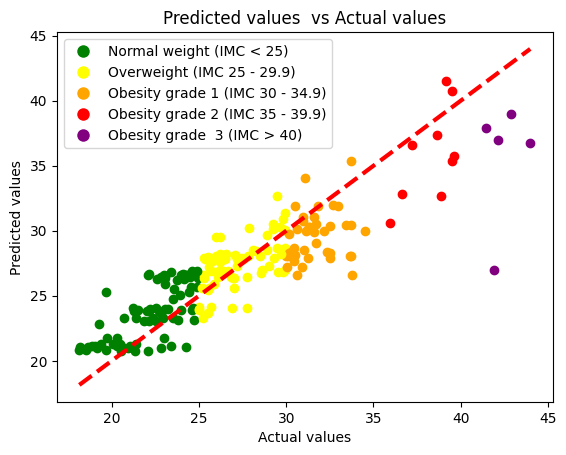

In [24]:
import matplotlib.pyplot as plt

# Definir los rangos de IMC y los colores correspondientes
rangos_imc = [(0, 25), (25, 30), (30, 35), (35, 40), (40, float('inf'))]
colores = ['green', 'yellow', 'orange', 'red', 'purple']
etiquetas = ['Normal weight (IMC < 25)', 'Overweight (IMC 25 - 29.9)', 'Obesity grade 1 (IMC 30 - 34.9)', 'Obesity grade 2 (IMC 35 - 39.9)', 'Obesity grade  3 (IMC > 40)']

# Colorear puntos según los niveles de IMC de y_test
for i in range(len(y_test)):
    imc = y_test.iloc[i]
    for j, (rango_inf, rango_sup) in enumerate(rangos_imc):
        if rango_inf <= imc < rango_sup:
            color = colores[j]
            plt.scatter(y_test.iloc[i], y_pred_rfr[i], color=color)
            break  # Rompe el bucle para evitar colorear el punto más de una vez

# Línea de referencia
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, color='red', label='Línea de referencia')

# Etiquetas y título
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Predicted values  vs Actual values')

# Agregar leyenda
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colores],
           labels=etiquetas, loc='best')

plt.show()

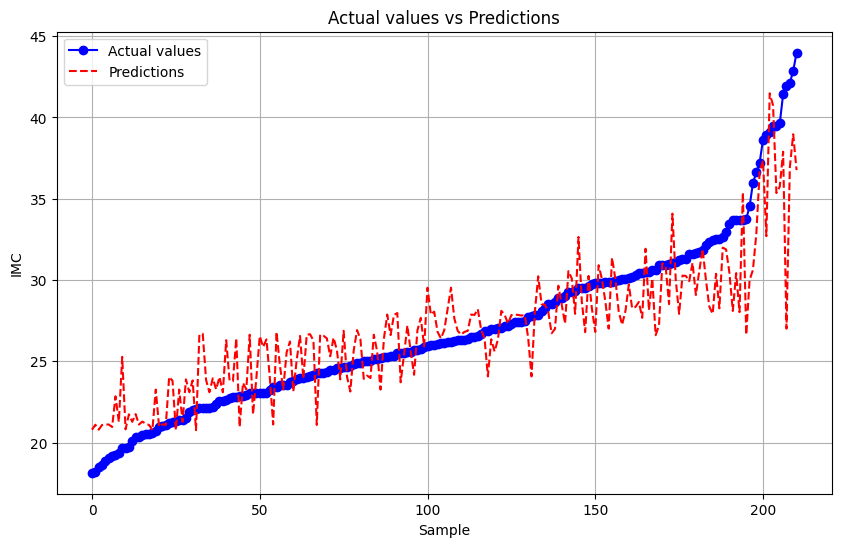

In [29]:
# Ordenar los índices de las muestras para una mejor visualización
sorted_indices = np.argsort(y_test)

# Graficar las predicciones versus los valores reales
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(y_test)), y_test.iloc[sorted_indices], label='Actual values', color='blue', marker='o')
plt.plot(np.arange(len(y_test)), y_pred_rfr[sorted_indices], label='Predictions', color='red', linestyle='--')
plt.xlabel('Sample')
plt.ylabel('IMC')
plt.title('Actual values vs Predictions')
plt.legend()
plt.grid(True)
plt.show()

#GradientBoostingRegressor

In [36]:
from sklearn.ensemble import GradientBoostingRegressor
import neptune
from neptune.types import File

# Define tags as a list
tags = ["experimento:Sobrepeso y Obesidad", "Arquitectura:GradientBoostingRegressor", "dataset:PRUEBA"]

# Definir hiperparámetros
hyperparameters = {
    "max_depth": 3,
    "n_estimators": 100,
    "learning_rate": 0.1,
    "min_samples_leaf": 10,
}

# Inicializar la ejecución de Neptune (reemplaza con tu API token e información del proyecto)
api_token = "eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIyNjQwNjNjMS1hNDcwLTRmOGItYTg1MC1hM2ZjM2MzZTZiMjcifQ=="
project = "lilekan39/GBR"
run = neptune.init_run(
    name = "GradientBoostingRegressor",
    project=project,
    api_token=api_token,
    tags=tags
)

# Registrar los hiperparámetros en Neptune
run["parameters"] = hyperparameters

# Crear y entrenar el modelo Gradient Boosting Regression
gbrt = GradientBoostingRegressor(**hyperparameters)
gbrt.fit(X_train, y_train)

# Hacer predicciones
y_pred_gbr = gbrt.predict(X_test)

# Calcular las métricas
from sklearn.metrics import mean_squared_error, r2_score

mse_gb = mean_squared_error(y_test, y_pred_gbr)
r2_gb = r2_score(y_test, y_pred_gbr)
mae_gb = mean_absolute_error(y_test, y_pred_gbr)
rmse_gb = np.sqrt(mse_gb)

# Registrar las métricas en Neptune
run["metrics/mse"] = mse_gb
run["metrics/r2"] = r2_gb
run["metrics/mae"] = mae_gb
run["metrics/rmse"] = rmse_gb

# Imprimir las métricas
print('MSE:', mse_gb)
print('R2:', r2_gb)
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)

# Opcionalmente, guardar el modelo como un artefacto de Neptune (si es compatible)
# if hasattr(run, 'log_artifact'):  # Verificar la disponibilidad de `log_artifact`
#     model_artifact = File(gbrt, name='model.pkl')  # Reemplazar con el formato de serialización adecuado
#     run.log_artifact(model_artifact)

# Detener la ejecución de Neptune
run.stop()

WritingToArchivedProjectException: 
[95m
----WritingToArchivedProjectException-----------------------------------------------------------------------
[0m
You're trying to write to a project that was archived.

Set the project as active again or use mode="read-only" at initialization to fetch metadata from it.

[92mNeed help?[0m-> https://docs-legacy.neptune.ai/help/error_writing_to_archived_project/


In [31]:
import matplotlib.pyplot as plt

# Definir los rangos de IMC y los colores correspondientes
rangos_imc = [(0, 25), (25, 30), (30, 35), (35, 40), (40, float('inf'))]
colores = ['green', 'yellow', 'orange', 'red', 'purple']
etiquetas = ['Normal weight (IMC < 25)', 'Overweight (IMC 25 - 29.9)', 'Obesity grade 1 (IMC 30 - 34.9)', 'Obesity grade 2 (IMC 35 - 39.9)', 'Obesity grade  3 (IMC > 40)']

# Colorear puntos según los niveles de IMC de y_test
for i in range(len(y_test)):
    imc = y_test.iloc[i]
    for j, (rango_inf, rango_sup) in enumerate(rangos_imc):
        if rango_inf <= imc < rango_sup:
            color = colores[j]
            plt.scatter(y_test.iloc[i], y_pred_gbr[i], color=color)
            break  # Rompe el bucle para evitar colorear el punto más de una vez

# Línea de referencia
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, color='red', label='Línea de referencia')

# Etiquetas y título
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Predicted values  vs Actual values')

# Agregar leyenda
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colores],
           labels=etiquetas, loc='best')

plt.show()

NameError: name 'y_pred_gbr' is not defined

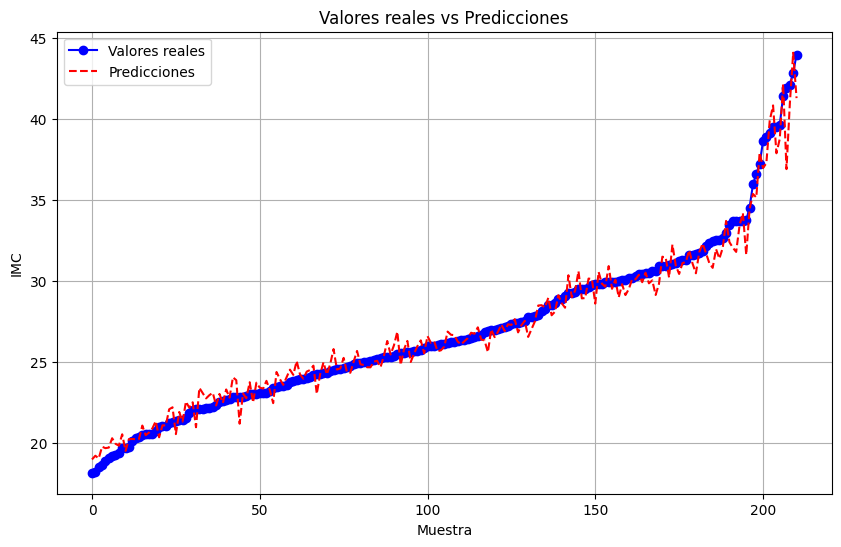

In [ ]:
# Ordenar los índices de las muestras para una mejor visualización
sorted_indices = np.argsort(y_test)

# Graficar las predicciones versus los valores reales
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(y_test)), y_test.iloc[sorted_indices], label='Actual values', color='blue', marker='o')
plt.plot(np.arange(len(y_test)), y_pred_gbr[sorted_indices], label='Predictions', color='red', linestyle='--')
plt.xlabel('Sample')
plt.ylabel('IMC')
plt.title('Actual values vs Predictions')
plt.legend()
plt.grid(True)
plt.show()

#xgb

In [32]:
import xgboost as xgb
import neptune
from neptune.types import File

# Define tags as a list
tags = ["experimento:Sobrepeso y Obesidad", "Arquitectura:xgb", "dataset:PRUEBA"]

# Initialize Neptune run (replace with your API token and project info)
api_token = "eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIyNjQwNjNjMS1hNDcwLTRmOGItYTg1MC1hM2ZjM2MzZTZiMjcifQ=="
project = "lilekan39/XGB"
run = neptune.init_run(
    project=project,
    api_token=api_token,
    tags=tags
)

# Define hyperparameters
hyperparameters = {
    "objective": "reg:squarederror",
    "max_depth": 3,
    "learning_rate": 0.1,
    "n_estimators": 100,
    "min_child_weight": 10,
}

# Log hyperparameters to Neptune
run["parameters"] = hyperparameters

# Train XGBoost model
xg_reg = xgb.XGBRegressor(**hyperparameters)
xg_reg.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xg_reg.predict(X_test)

# Calculate and log metrics to Neptune
from sklearn.metrics import mean_squared_error, r2_score

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

run["metrics/mse"] = mse_xgb
run["metrics/r2"] = r2_xgb
run["metrics/mae"] = mae_xgb
run["metrics/rmse"] = rmse_xgb

print('MSE:', mse_xgb)
print('R2:', r2_xgb)
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

# Optionally save the model as a Neptune artifact (if supported)
# if hasattr(run, 'log_artifact'):  # Check if log_artifact is available
#     model_artifact = File(xg_reg, name='model.pkl')  # Replace with appropriate serialization format
#     run.log_artifact(model_artifact)

# Stop Neptune run
run.stop()

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/lilekan39/XGB/e/XGB-152
MSE: 0.692407869896686
R2: 0.9739584584242167
MAE: 0.6000549393455186
RMSE: 0.8321104913992408
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 9 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 9 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/lilekan39/XGB/e/XGB-152/metadata


<ipython-input-33-4252d89f4acd>:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, color='red', label='Línea de referencia')


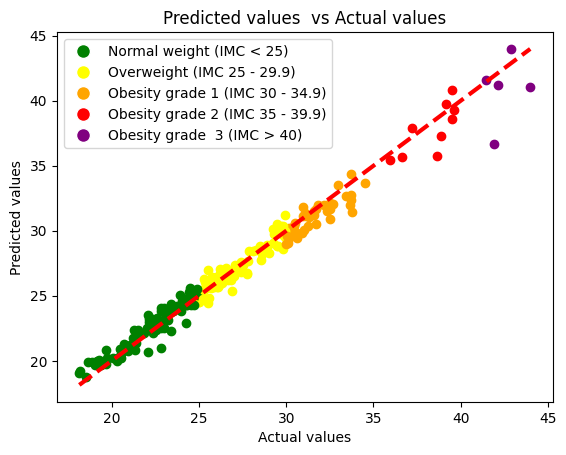

In [33]:
import matplotlib.pyplot as plt

# Definir los rangos de IMC y los colores correspondientes
rangos_imc = [(0, 25), (25, 30), (30, 35), (35, 40), (40, float('inf'))]
colores = ['green', 'yellow', 'orange', 'red', 'purple']
etiquetas = ['Normal weight (IMC < 25)', 'Overweight (IMC 25 - 29.9)', 'Obesity grade 1 (IMC 30 - 34.9)', 'Obesity grade 2 (IMC 35 - 39.9)', 'Obesity grade  3 (IMC > 40)']

# Colorear puntos según los niveles de IMC de y_test
for i in range(len(y_test)):
    imc = y_test.iloc[i]
    for j, (rango_inf, rango_sup) in enumerate(rangos_imc):
        if rango_inf <= imc < rango_sup:
            color = colores[j]
            plt.scatter(y_test.iloc[i], y_pred_xgb[i], color=color)
            break  # Rompe el bucle para evitar colorear el punto más de una vez

# Línea de referencia
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, color='red', label='Línea de referencia')

# Etiquetas y título
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Predicted values  vs Actual values')
# Agregar leyenda
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colores],
           labels=etiquetas, loc='best')

plt.show()

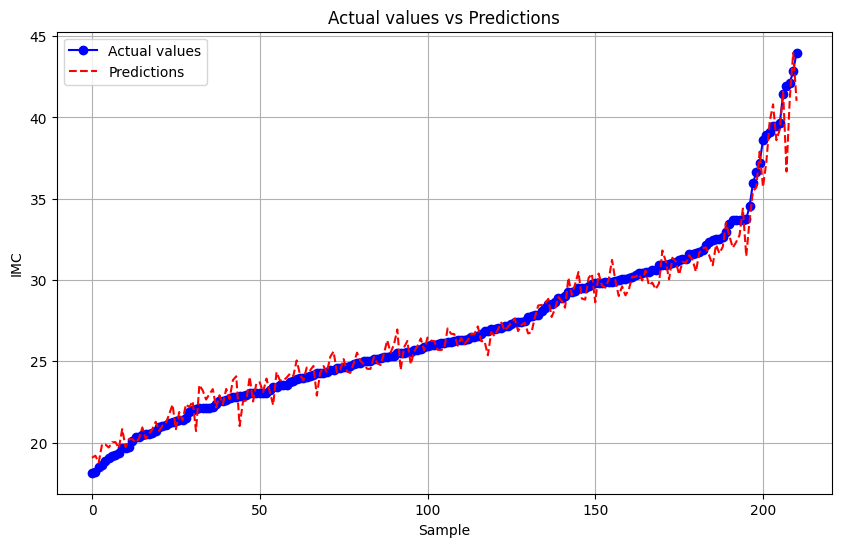

In [34]:
# Ordenar los índices de las muestras para una mejor visualización
sorted_indices = np.argsort(y_test)

# Graficar las predicciones versus los valores reales
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(y_test)), y_test.iloc[sorted_indices], label='Actual values', color='blue', marker='o')
plt.plot(np.arange(len(y_test)), y_pred_xgb[sorted_indices], label='Predictions', color='red', linestyle='--')
plt.xlabel('Sample')
plt.ylabel('IMC')
plt.title('Actual values vs Predictions')
plt.legend()
plt.grid(True)
plt.show()